# Hospital Patient Analysis — SQL Portfolio Project

**Dataset:** Kaggle Healthcare Dataset · 55,500 admissions · 2019–2024  
**Approach:** Raw CSV normalised into 5 relational tables, loaded into SQLite, then analysed with SQL using JOINs, aggregations, and window functions.

**Business questions answered:**
1. Which medical conditions drive the longest stays and highest costs?
2. How does billing vary by insurance provider?
3. Which patients were readmitted — and what conditions keep bringing them back?
4. How have monthly admissions trended, and what is the month-over-month change?
5. Which doctors handle the most patients, ranked within each condition?

---
## Part 1 — Load Raw Data & Normalise into Relational Tables

In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 10})

raw = pd.read_csv('healthcare_dataset.csv')
raw['Name'] = raw['Name'].str.title()  # fix mixed-case names like 'Bobby JacksOn'

print(f"Raw rows loaded : {len(raw):,}")
print(f"Date range      : {raw['Date of Admission'].min()} to {raw['Date of Admission'].max()}")
raw.head(3)

Raw rows loaded : 55,500
Date range      : 2019-05-08 to 2024-05-07


,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby Jackson,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,Leslie Terry,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,Danny Smith,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal


In [2]:
# ── PATIENTS ──────────────────────────────────────────────────────────────────
patients = (
    raw.sort_values('Date of Admission', ascending=False)
       .drop_duplicates(subset='Name')
       [['Name', 'Age', 'Gender', 'Blood Type']]
       .reset_index(drop=True)
)
patients.insert(0, 'patient_id', range(1, len(patients) + 1))
patients.columns = ['patient_id', 'name', 'age', 'gender', 'blood_type']

# ── DOCTORS ───────────────────────────────────────────────────────────────────
doctors = pd.DataFrame({'doctor_name': raw['Doctor'].unique()}).reset_index(drop=True)
doctors.insert(0, 'doctor_id', range(1, len(doctors) + 1))

# ── HOSPITALS ─────────────────────────────────────────────────────────────────
hospitals = pd.DataFrame({'hospital_name': raw['Hospital'].unique()}).reset_index(drop=True)
hospitals.insert(0, 'hospital_id', range(1, len(hospitals) + 1))

# ── ADMISSIONS ────────────────────────────────────────────────────────────────
df = raw.merge(patients[['patient_id', 'name']], left_on='Name', right_on='name', how='left')
df = df.merge(doctors,   left_on='Doctor',   right_on='doctor_name',   how='left')
df = df.merge(hospitals, left_on='Hospital', right_on='hospital_name', how='left')

admissions = df[['patient_id', 'doctor_id', 'hospital_id',
                 'Date of Admission', 'Discharge Date',
                 'Admission Type', 'Room Number',
                 'Medical Condition', 'Test Results']].copy()
admissions.insert(0, 'admission_id', range(1, len(admissions) + 1))
admissions.columns = ['admission_id', 'patient_id', 'doctor_id', 'hospital_id',
                      'date_of_admission', 'discharge_date',
                      'admission_type', 'room_number',
                      'medical_condition', 'test_results']

# ── BILLING ───────────────────────────────────────────────────────────────────
billing = df[['Insurance Provider', 'Billing Amount', 'Medication']].copy()
billing.insert(0, 'billing_id',   range(1, len(billing) + 1))
billing.insert(1, 'admission_id', range(1, len(billing) + 1))
billing.columns = ['billing_id', 'admission_id',
                   'insurance_provider', 'billing_amount', 'medication']

print(f"patients  : {len(patients):>6,} rows")
print(f"doctors   : {len(doctors):>6,} rows")
print(f"hospitals : {len(hospitals):>6,} rows")
print(f"admissions: {len(admissions):>6,} rows")
print(f"billing   : {len(billing):>6,} rows")

patients  : 40,235 rows
doctors   : 40,341 rows
hospitals : 39,876 rows
admissions: 55,500 rows
billing   : 55,500 rows


In [3]:
DB   = 'hospital.db'
conn = sqlite3.connect(DB)

patients.to_sql('patients',     conn, if_exists='replace', index=False)
doctors.to_sql('doctors',       conn, if_exists='replace', index=False)
hospitals.to_sql('hospitals',   conn, if_exists='replace', index=False)
admissions.to_sql('admissions', conn, if_exists='replace', index=False)
billing.to_sql('billing',       conn, if_exists='replace', index=False)

print(f"All 5 tables written to {DB}")
for tbl in ['patients', 'doctors', 'hospitals', 'admissions', 'billing']:
    n = conn.execute(f'SELECT COUNT(*) FROM {tbl}').fetchone()[0]
    print(f"  {tbl:<12}: {n:,} rows")

All 5 tables written to hospital.db
  patients    : 40,235 rows
  doctors     : 40,341 rows
  hospitals   : 39,876 rows
  admissions  : 55,500 rows
  billing     : 55,500 rows


### Database Schema
```
patients    (patient_id PK, name, age, gender, blood_type)
doctors     (doctor_id PK, doctor_name)
hospitals   (hospital_id PK, hospital_name)
admissions  (admission_id PK, patient_id FK, doctor_id FK, hospital_id FK,
             date_of_admission, discharge_date, admission_type,
             room_number, medical_condition, test_results)
billing     (billing_id PK, admission_id FK,
             insurance_provider, billing_amount, medication)
```

---
## Q1 — Which medical conditions drive the longest stays and highest costs?
*Techniques: JOIN · AVG · COUNT · JULIANDAY date arithmetic · GROUP BY*

medical_condition  total_admissions  avg_stay_days  avg_billing_usd  total_revenue_usd
           Asthma              9185           15.7         25635.25       235459765.36
          Obesity              9231           15.5         25805.97       238214920.69
     Hypertension              9245           15.5         25497.10       235720650.31
           Cancer              9227           15.5         25161.79       232167861.31
        Arthritis              9308           15.5         25497.33       237329120.23
         Diabetes              9304           15.4         25638.41       238539725.49


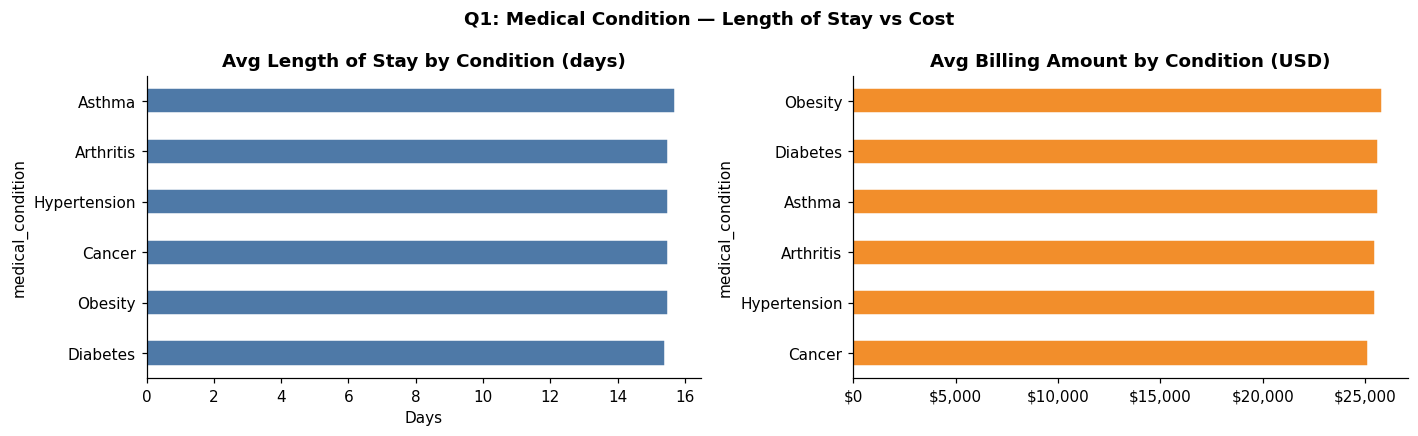


Insight: Asthma has the longest average stay (15.7 days) with average billing of $25,635.25 per admission.


In [4]:
q1 = pd.read_sql('''
    SELECT
        a.medical_condition,
        COUNT(*)                                                              AS total_admissions,
        ROUND(AVG(JULIANDAY(a.discharge_date)
                - JULIANDAY(a.date_of_admission)), 1)                        AS avg_stay_days,
        ROUND(AVG(b.billing_amount), 2)                                      AS avg_billing_usd,
        ROUND(SUM(b.billing_amount), 2)                                      AS total_revenue_usd
    FROM admissions a
    JOIN billing b ON a.admission_id = b.admission_id
    GROUP BY a.medical_condition
    ORDER BY avg_stay_days DESC
''', conn)

print(q1.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

q1.set_index('medical_condition')['avg_stay_days'].sort_values().plot(
    kind='barh', ax=axes[0], color='#4e79a7', edgecolor='white')
axes[0].set_title('Avg Length of Stay by Condition (days)', fontweight='bold')
axes[0].set_xlabel('Days')

q1.set_index('medical_condition')['avg_billing_usd'].sort_values().plot(
    kind='barh', ax=axes[1], color='#f28e2b', edgecolor='white')
axes[1].set_title('Avg Billing Amount by Condition (USD)', fontweight='bold')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.suptitle('Q1: Medical Condition — Length of Stay vs Cost', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

top = q1.iloc[0]
print(f"\nInsight: {top['medical_condition']} has the longest average stay "
      f"({top['avg_stay_days']} days) with average billing of ${top['avg_billing_usd']:,.2f} per admission.")

---
## Q2 — How does billing vary by insurance provider?
*Techniques: JOIN · SUM · AVG · MIN · MAX · GROUP BY · ORDER BY*

insurance_provider  total_claims  avg_claim_usd  min_claim_usd  max_claim_usd  total_revenue_usd
             Cigna         11249       25525.77       -1520.42       52170.04       287139345.27
          Medicare         11154       25615.99       -1277.65       52092.67       285720758.13
        Blue Cross         11059       25613.01       -1660.01       52764.28       283254294.21
  UnitedHealthcare         11125       25389.17       -1428.84       52373.03       282454542.84
             Aetna         10913       25553.29       -2008.49       52211.85       278863102.95


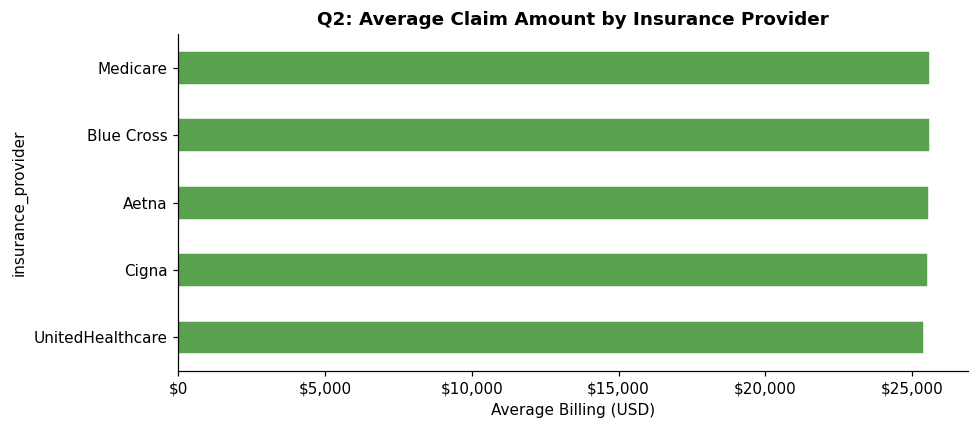


Insight: Cigna processes the most total revenue ($287,139,345) across 11,249 claims.


In [5]:
q2 = pd.read_sql('''
    SELECT
        b.insurance_provider,
        COUNT(*)                            AS total_claims,
        ROUND(AVG(b.billing_amount), 2)     AS avg_claim_usd,
        ROUND(MIN(b.billing_amount), 2)     AS min_claim_usd,
        ROUND(MAX(b.billing_amount), 2)     AS max_claim_usd,
        ROUND(SUM(b.billing_amount), 2)     AS total_revenue_usd
    FROM billing b
    JOIN admissions a ON b.admission_id = a.admission_id
    GROUP BY b.insurance_provider
    ORDER BY total_revenue_usd DESC
''', conn)

print(q2.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4))
q2.set_index('insurance_provider')['avg_claim_usd'].sort_values().plot(
    kind='barh', ax=ax, color='#59a14f', edgecolor='white')
ax.set_title('Q2: Average Claim Amount by Insurance Provider', fontweight='bold')
ax.set_xlabel('Average Billing (USD)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

top = q2.iloc[0]
print(f"\nInsight: {top['insurance_provider']} processes the most total revenue "
      f"(${top['total_revenue_usd']:,.0f}) across {top['total_claims']:,} claims.")

---
## Q3 — Which patients were readmitted, and what conditions keep bringing them back?
*Techniques: CTE · COUNT() OVER (PARTITION BY) window function · JOIN across 3 tables · GROUP_CONCAT*

In [6]:
q3 = pd.read_sql('''
    WITH admission_counts AS (
        SELECT
            patient_id,
            COUNT(*) OVER (PARTITION BY patient_id) AS total_admissions
        FROM admissions
    ),
    readmitted AS (
        SELECT DISTINCT patient_id
        FROM   admission_counts
        WHERE  total_admissions > 1
    )
    SELECT
        p.name,
        p.age,
        p.gender,
        COUNT(a.admission_id)                       AS admissions,
        GROUP_CONCAT(DISTINCT a.medical_condition)  AS conditions,
        ROUND(SUM(b.billing_amount), 2)             AS total_billed_usd
    FROM readmitted r
    JOIN patients   p ON r.patient_id   = p.patient_id
    JOIN admissions a ON p.patient_id   = a.patient_id
    JOIN billing    b ON a.admission_id = b.admission_id
    GROUP BY p.patient_id, p.name, p.age, p.gender
    ORDER BY admissions DESC, total_billed_usd DESC
    LIMIT 15
''', conn)

print("Top 15 readmitted patients:")
print(q3.to_string(index=False))

readmit_count = pd.read_sql('''
    SELECT COUNT(*) AS n FROM (
        SELECT patient_id FROM admissions
        GROUP BY patient_id HAVING COUNT(*) > 1
    )
''', conn).iloc[0, 0]

total_patients = pd.read_sql('SELECT COUNT(*) FROM patients', conn).iloc[0, 0]
print(f"\nInsight: {readmit_count:,} of {total_patients:,} patients "
      f"({readmit_count/total_patients:.1%}) had more than one admission.")

Top 15 readmitted patients:
             name  age gender  admissions                                            conditions  total_billed_usd
 Michael Williams   29 Female          24 Cancer,Hypertension,Diabetes,Obesity,Asthma,Arthritis         555240.70
    Michael Smith   39   Male          23 Obesity,Arthritis,Hypertension,Cancer,Diabetes,Asthma         660173.09
     Robert Smith   65   Male          22 Arthritis,Hypertension,Asthma,Obesity,Diabetes,Cancer         573407.94
      James Brown   49 Female          19 Diabetes,Asthma,Arthritis,Obesity,Hypertension,Cancer         452411.25
      James Smith   54 Female          18 Asthma,Cancer,Diabetes,Obesity,Hypertension,Arthritis         468220.24
   James Williams   53   Male          17 Arthritis,Obesity,Diabetes,Hypertension,Asthma,Cancer         471240.45
    David Johnson   49   Male          16           Asthma,Hypertension,Obesity,Cancer,Diabetes         457290.17
       John Smith   72 Female          16 Diabetes,Asthma,Ar

---
## Q4 — How have monthly admissions trended, and what is the month-over-month change?
*Techniques: CTE · STRFTIME date grouping · LAG() OVER (ORDER BY) window function*

Last 12 months:
  month  admissions  prev_month  mom_change
2023-06         961       927.0        34.0
2023-07         919       961.0       -42.0
2023-08         968       919.0        49.0
2023-09         920       968.0       -48.0
2023-10         898       920.0       -22.0
2023-11         881       898.0       -17.0
2023-12         921       881.0        40.0
2024-01         909       921.0       -12.0
2024-02         880       909.0       -29.0
2024-03         906       880.0        26.0
2024-04         946       906.0        40.0
2024-05         213       946.0      -733.0


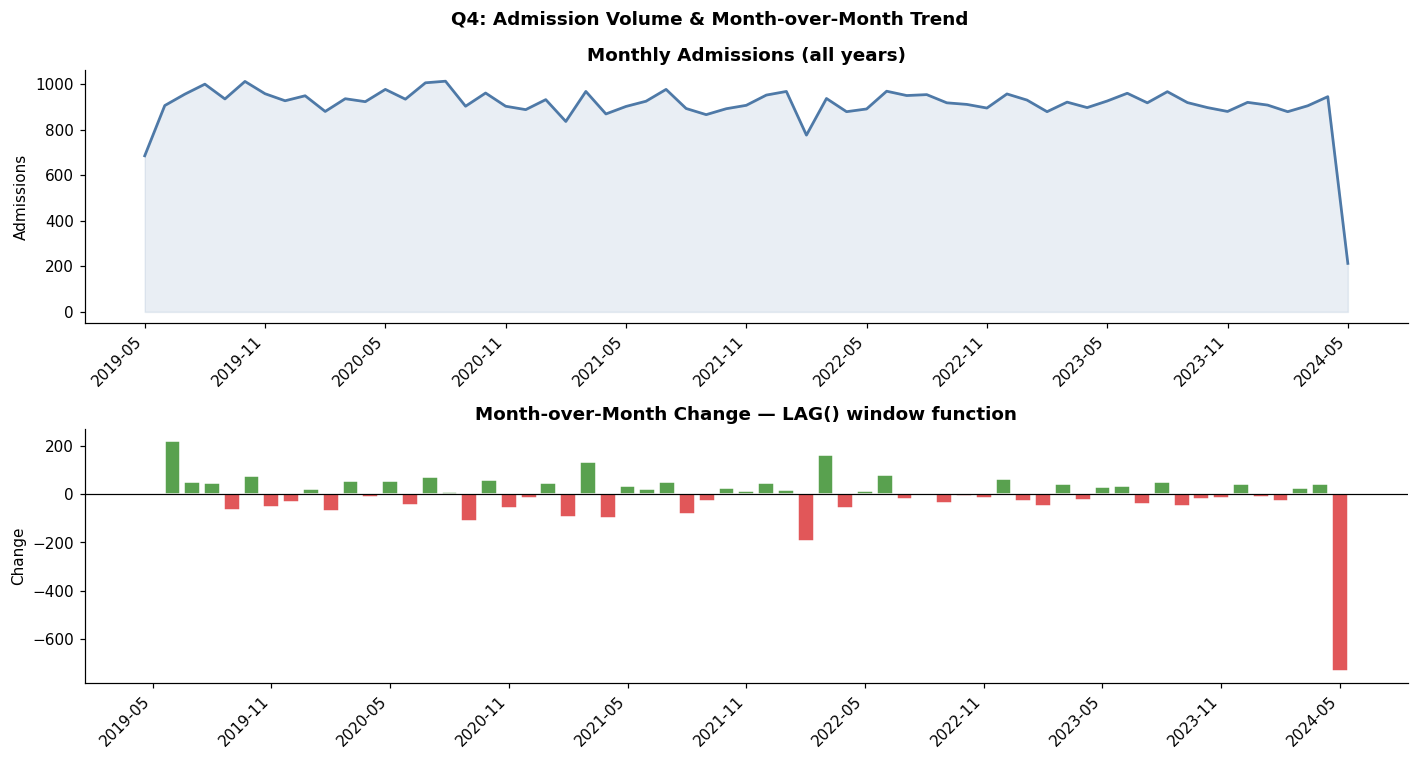


Insight: Peak admissions were in 2020-08 with 1,014 cases.


In [7]:
q4 = pd.read_sql('''
    WITH monthly AS (
        SELECT
            STRFTIME('%Y-%m', date_of_admission) AS month,
            COUNT(*)                              AS admissions
        FROM admissions
        GROUP BY month
    )
    SELECT
        month,
        admissions,
        LAG(admissions) OVER (ORDER BY month)                  AS prev_month,
        admissions - LAG(admissions) OVER (ORDER BY month)     AS mom_change
    FROM monthly
    ORDER BY month
''', conn)

print("Last 12 months:")
print(q4.tail(12).to_string(index=False))

fig, axes = plt.subplots(2, 1, figsize=(13, 7))

axes[0].plot(range(len(q4)), q4['admissions'], color='#4e79a7', linewidth=1.8)
axes[0].fill_between(range(len(q4)), q4['admissions'], alpha=0.12, color='#4e79a7')
axes[0].set_title('Monthly Admissions (all years)', fontweight='bold')
axes[0].set_xticks(range(0, len(q4), 6))
axes[0].set_xticklabels(q4['month'].iloc[::6], rotation=45, ha='right')
axes[0].set_ylabel('Admissions')

colors = ['#e15759' if v < 0 else '#59a14f' for v in q4['mom_change'].fillna(0)]
axes[1].bar(range(len(q4)), q4['mom_change'].fillna(0), color=colors, edgecolor='white')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Month-over-Month Change — LAG() window function', fontweight='bold')
axes[1].set_xticks(range(0, len(q4), 6))
axes[1].set_xticklabels(q4['month'].iloc[::6], rotation=45, ha='right')
axes[1].set_ylabel('Change')

plt.suptitle('Q4: Admission Volume & Month-over-Month Trend', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

peak = q4.loc[q4['admissions'].idxmax()]
print(f"\nInsight: Peak admissions were in {peak['month']} with {peak['admissions']:,} cases.")

---
## Q5 — Which doctors handle the most patients, ranked within each condition?
*Techniques: CTE · JOIN across 3 tables · RANK() OVER (PARTITION BY medical_condition ORDER BY patient_count DESC)*

In [ ]:
q5 = pd.read_sql('''\n    WITH doctor_condition AS (\n        SELECT\n            d.doctor_name,\n            a.medical_condition,\n            COUNT(*)                        AS patients_treated,\n            ROUND(AVG(b.billing_amount), 2) AS avg_billing\n        FROM admissions a\n        JOIN doctors d ON a.doctor_id    = d.doctor_id\n        JOIN billing b ON a.admission_id = b.admission_id\n        GROUP BY d.doctor_id, d.doctor_name, a.medical_condition\n    ),\n    ranked AS (\n        SELECT\n            medical_condition,\n            doctor_name,\n            patients_treated,\n            avg_billing,\n            RANK() OVER (\n                PARTITION BY medical_condition\n                ORDER BY patients_treated DESC\n            ) AS rank_in_condition\n        FROM doctor_condition\n    )\n    SELECT *\n    FROM   ranked\n    WHERE  rank_in_condition <= 3\n    ORDER BY medical_condition, rank_in_condition\n''', conn)\n\nprint("Top 3 doctors per condition (by patient volume):")\nprint(q5.to_string(index=False))\n\nfig, ax = plt.subplots(figsize=(10, 5))\ntop_per_condition = q5[q5['rank_in_condition'] == 1].set_index('medical_condition')\ntop_per_condition['patients_treated'].plot(\n    kind='bar', ax=ax, color='#b07aa1', edgecolor='white', rot=30)\nax.set_title('Q5: #1 Ranked Doctor per Condition — Patients Treated', fontweight='bold')\nax.set_ylabel('Patients Treated')\nax.set_xlabel('')\nplt.tight_layout()\nplt.show()\n\nprint("\\nInsight: RANK() OVER (PARTITION BY condition) compares each doctor only against"\n      " peers in the same specialty — giving a fairer ranking than sorting the full list.")

---
## Summary

| Question | SQL Techniques |
|---|---|
| Q1: Condition — stay length & cost | JOIN · AVG · COUNT · JULIANDAY · GROUP BY |
| Q2: Insurance provider billing | JOIN · SUM · AVG · MIN · MAX · GROUP BY |
| Q3: Readmission analysis | CTE · COUNT() OVER PARTITION BY · 3-table JOIN · GROUP_CONCAT |
| Q4: Monthly trend & MoM change | CTE · STRFTIME · LAG() OVER ORDER BY |
| Q5: Doctor ranking per condition | CTE · 3-table JOIN · RANK() OVER PARTITION BY |

**Dataset note:** Synthetic dataset from Kaggle (prasad22), generated to resemble real patient records. Values are statistically plausible but not derived from actual clinical data.

In [9]:
conn.close()
print("Database connection closed.")

Database connection closed.
